<a href="https://colab.research.google.com/github/DhruvGangwar320/GitHUB/blob/main/how_model_trains.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("headbrain.csv")

In [ ]:
df.shape

(237, 4)

In [ ]:
df.head()

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [ ]:
# we need only two columns Head Size and Brain Weight
X = df["Head Size(cm^3)"].values
Y = df["Brain Weight(grams)"].values


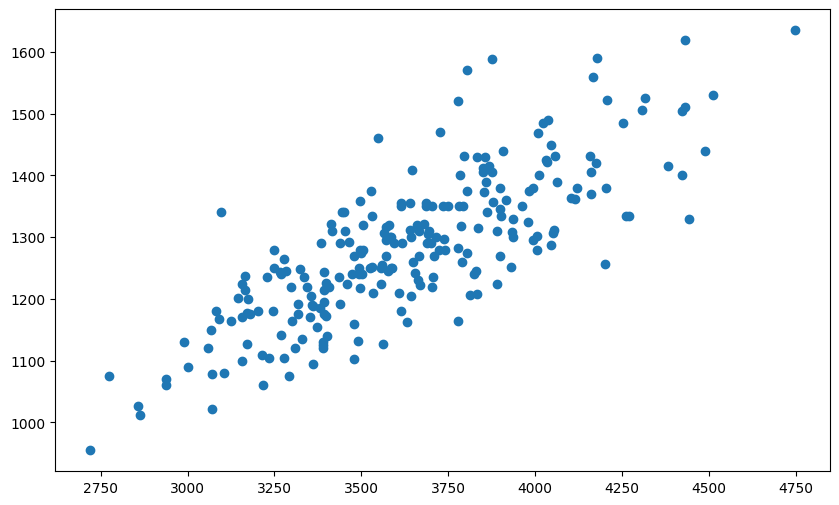

In [ ]:
plt.figure(figsize = (10,6))
plt.scatter(X,Y)
plt.show()

In [ ]:
mean_x = np.mean(X)
mean_y = np.mean(Y)

In [ ]:
numer =0
denom = 0

n = len(X)

for i in range(n):
  numer += (Y[i] - mean_y)*(X[i] -mean_x)
  denom += (X[i] - mean_x)**2
slope = numer / denom
intercept = mean_y - (slope*mean_x)


In [ ]:
print("Slope : ", slope)
print("Intercept : ",intercept)

Slope :  0.26342933948939945
Intercept :  325.57342104944223


In [ ]:
predictions = []
for i in range(n):
  y_pred  = slope * X[i] + intercept
  predictions.append(int(y_pred))

In [ ]:
# Predicted values
print(predictions[:5])

[1514, 1310, 1448, 1320, 1425]


In [ ]:
# Actual Values
print(Y[:5])


[1530 1297 1335 1282 1590]


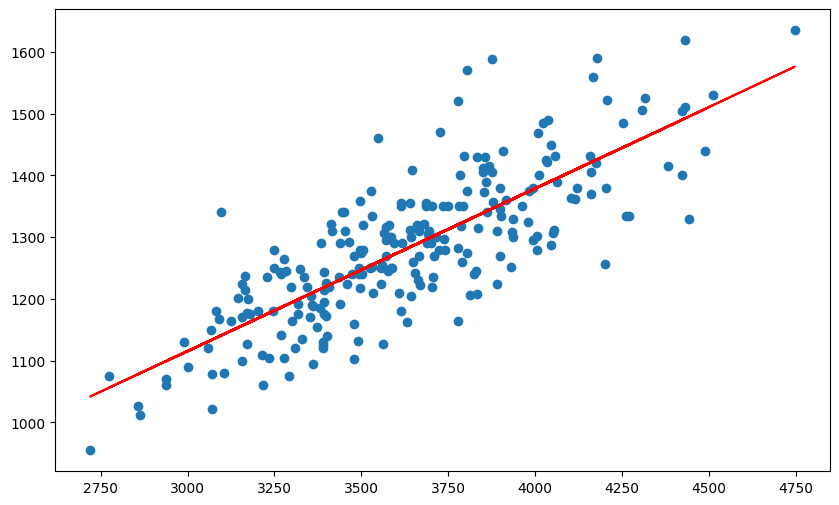

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X,Y)
plt.plot(X,predictions,'r')
plt.show()

In [ ]:
#MSE mean sqaured error
error = 0
for i in range(n):
  error+= (predictions[i] - Y[i])**2
mse = error / n
print('MSE : ' , mse)

MSE :  5202.9029535864975


In [ ]:
# RMSE root mean square error
np.sqrt(mse)

np.float64(72.13115106239812)

##GRADIENT DESCENT BASED SLOPE AND INTERCEPT

In [ ]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
X.shape

(237,)

In [ ]:
# making data in 2d format for MinMaxScaler()
X = np.reshape(X,(-1,1)) # -1 calculates the rows by its own
Y = np.reshape(Y,(-1,1))


In [ ]:
X.shape

(237, 1)

In [ ]:
minmax = MinMaxScaler()
scale_x = minmax.fit_transform(X)
scale_y = minmax.fit_transform(Y)

In [ ]:
print(scale_x[:5])

[[0.88406512]
 [0.50222003]
 [0.7602368 ]
 [0.52146029]
 [0.71879625]]


In [ ]:
def gradientDescent(epochs , alpha):
  slope = 0.0
  inter = 0.0
  for i in range(epochs):
    y_pred = (slope * scale_x) + inter
    loss = y_pred - scale_y
    gradSlope = (2/n) * np.dot(loss.T,scale_x)
    gradInter = (2/n) * np.sum(loss)
    slope = slope - gradSlope * alpha
    inter = inter - gradInter * alpha
  return slope , inter

In [ ]:
epochs = 9000
alpha = 0.01
slope,inter=  gradientDescent(epochs,alpha)
print("New Slope :",slope)
print("New Intercept : ", inter)

New Slope : [[0.78041018]]
New Intercept :  0.13033319244733121


In [ ]:
predictions = []
for i in range(n):
  y_pred = slope[0][0] * scale_x[i] + inter
  predictions.append(y_pred)


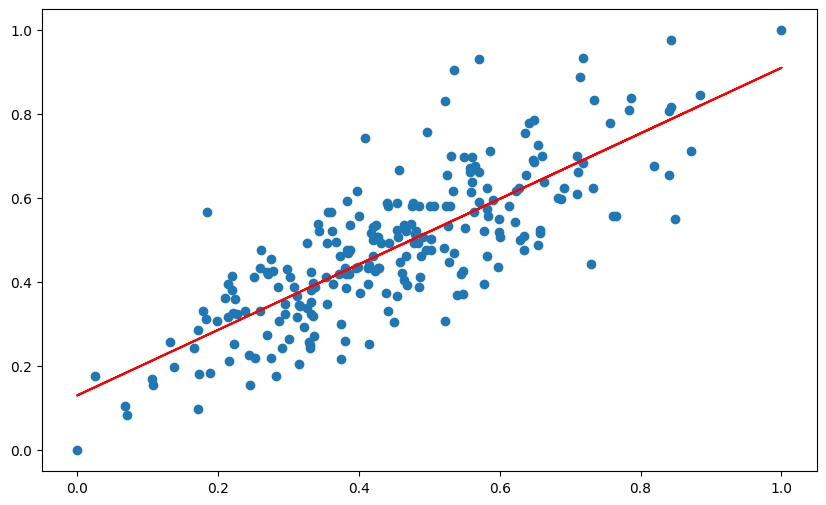

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(scale_x,scale_y)
plt.plot(scale_x,predictions, 'r')
plt.show()